In [1]:
#Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pathlib import Path
sns.set_theme(style="whitegrid")


EDA on people data

## Summary

This notebook profiles the dietary records and participant metadata.

The analysis includes:
- Loading daily dietary records from `nutrition_totals.txt`.
- Selecting key dietary variables: calories (`KCAL`), fiber (`FIBE`), carbohydrates (`CARB`), and total fat (`TFAT`).
- Calculating missing-value percentages for dietary variables.
- Visualizing missing values using `missingno`.
- Aggregating dietary records into average intake per participant.
- Loading participant metadata from `food_map.txt`.
- Adding participant-level characteristics: `Age` and `BMI`.
- Plotting histograms and boxplots for nutrient intake and participant characteristics.

These variables can later be used as control variables / confounders in downstream microbiome analysis.

In [2]:
# Define file paths

base_dir = Path.cwd()

#diet_dir = base_dir / "dietstudy_analyses-master" / "data" / "diet"
#maps_dir = base_dir / "dietstudy_analyses-master" / "data" / "maps"
diet_dir = base_dir / "data" / "dietstudy_analyses-master" / "data" / "diet"
maps_dir = base_dir / "data" / "dietstudy_analyses-master" / "data" / "maps"

nutrition_path = diet_dir / "nutrition_totals.txt"
metadata_path = maps_dir / "food_map.txt"

print("Nutrition path exists:", nutrition_path.exists())
print("Nutrition path:", nutrition_path)

print("Metadata path exists:", metadata_path.exists())
print("Metadata path:", metadata_path)

# print("\nFiles in maps directory:")z
# for file in maps_dir.iterdir():
#     print(file.name)
    

Nutrition path exists: True
Nutrition path: c:\Users\ayele\OneDrive\Desktop\year 3\project\data\dietstudy_analyses-master\data\diet\nutrition_totals.txt
Metadata path exists: True
Metadata path: c:\Users\ayele\OneDrive\Desktop\year 3\project\data\dietstudy_analyses-master\data\maps\food_map.txt


In [3]:
# Load the nutrition totals data

df_nutrients = pd.read_csv(nutrition_path, sep="\t")

df_nutrients.columns = df_nutrients.columns.str.strip()

print("Nutrients shape:", df_nutrients.shape)

display(df_nutrients.head())

print("Nutrient columns:")
print(df_nutrients.columns.tolist())

Nutrients shape: (580, 107)


,X.SampleID,UserName,StudyDayNo,RecordDayNo,KCAL,PROT,TFAT,CARB,MOIS,ALC,...,PF_LEGUMES,D_TOTAL,D_MILK,D_YOGURT,D_CHEESE,OILS,SOLID_FATS,ADD_SUGARS,A_DRINKS,Replicate
0,MCT.f.0001,MCTs01,Day.01,1,1707.040193,95.668747,55.185318,187.965353,3848.605502,14.95872,...,0.0,3.265577,2.05776,0.646,0.561817,14.668870,21.795872,4.822350,1.072512,1
1,MCT.f.0002,MCTs01,Day.02,2,1970.043625,109.619765,53.615264,242.919015,3808.005721,14.04000,...,0.0,4.156035,2.35656,0.646,1.153475,15.886225,19.139825,4.325970,1.008000,1
2,MCT.f.0003,MCTs01,Day.03,3,1714.895330,89.992993,50.561373,234.225138,4183.622433,0.00000,...,0.0,2.979655,1.12608,0.646,1.207575,11.836920,17.711575,4.758330,0.000000,1
3,MCT.f.0004,MCTs01,Day.04,4,2487.232625,94.611953,92.021551,257.539030,4816.211548,42.44800,...,0.0,3.634460,2.15186,0.000,1.482600,55.308100,19.937800,5.917100,3.035200,1
4,MCT.f.0005,MCTs01,Day.05,5,2260.211176,110.268353,95.570253,165.608070,4404.243876,43.93060,...,0.0,3.379710,2.32071,0.000,1.059000,24.231213,54.613613,5.793898,3.116360,1


Nutrient columns:
['X.SampleID', 'UserName', 'StudyDayNo', 'RecordDayNo', 'KCAL', 'PROT', 'TFAT', 'CARB', 'MOIS', 'ALC', 'CAFF', 'THEO', 'SUGR', 'FIBE', 'CALC', 'IRON', 'MAGN', 'PHOS', 'POTA', 'SODI', 'ZINC', 'COPP', 'SELE', 'VC', 'VB1', 'VB2', 'NIAC', 'VB6', 'FOLA', 'FA', 'FF', 'FDFE', 'VB12', 'VARA', 'RET', 'BCAR', 'ACAR', 'CRYP', 'LYCO', 'LZ', 'ATOC', 'VK', 'CHOLE', 'SFAT', 'S040', 'S060', 'S080', 'S100', 'S120', 'S140', 'S160', 'S180', 'MFAT', 'M161', 'M181', 'M201', 'M221', 'PFAT', 'P182', 'P183', 'P184', 'P204', 'P205', 'P225', 'P226', 'VITD', 'CHOLN', 'VITE_ADD', 'B12_ADD', 'F_TOTAL', 'F_CITMLB', 'F_OTHER', 'F_JUICE', 'V_TOTAL', 'V_DRKGR', 'V_REDOR_TOTAL', 'V_REDOR_TOMATO', 'V_REDOR_OTHER', 'V_STARCHY_TOTAL', 'V_STARCHY_POTATO', 'V_STARCHY_OTHER', 'V_OTHER', 'V_LEGUMES', 'G_TOTAL', 'G_WHOLE', 'G_REFINED', 'PF_TOTAL', 'PF_MPS_TOTAL', 'PF_MEAT', 'PF_CUREDMEAT', 'PF_ORGAN', 'PF_POULT', 'PF_SEAFD_HI', 'PF_SEAFD_LOW', 'PF_EGGS', 'PF_SOY', 'PF_NUTSDS', 'PF_LEGUMES', 'D_TOTAL', 'D_MILK

In [4]:
# Define expected nutrient columns and check which ones are present

nutrient_columns = ["KCAL", "FIBE", "CARB"]

# Try to add fat column automatically if it exists under a common name
fat_candidates = ["FAT", "TFAT", "TotalFat", "Fat", "Total_Fat"]

for col in fat_candidates:
    if col in df_nutrients.columns:
        nutrient_columns.append(col)
        break

existing_nutrient_columns = [col for col in nutrient_columns if col in df_nutrients.columns]

print("Selected nutrient columns:")
print(existing_nutrient_columns)

print("\nMissing expected columns:")
print(set(nutrient_columns) - set(existing_nutrient_columns))

Selected nutrient columns:
['KCAL', 'FIBE', 'CARB', 'TFAT']

Missing expected columns:
set()


In [5]:
# Analyze missing data in the selected nutrient columns

missing_percentages = (
    df_nutrients[existing_nutrient_columns]
    .isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_df = missing_percentages.reset_index()
missing_df.columns = ["Feature", "Missing Percentage"]

display(missing_df)

,Feature,Missing Percentage
0,KCAL,0.0
1,FIBE,0.0
2,CARB,0.0
3,TFAT,0.0


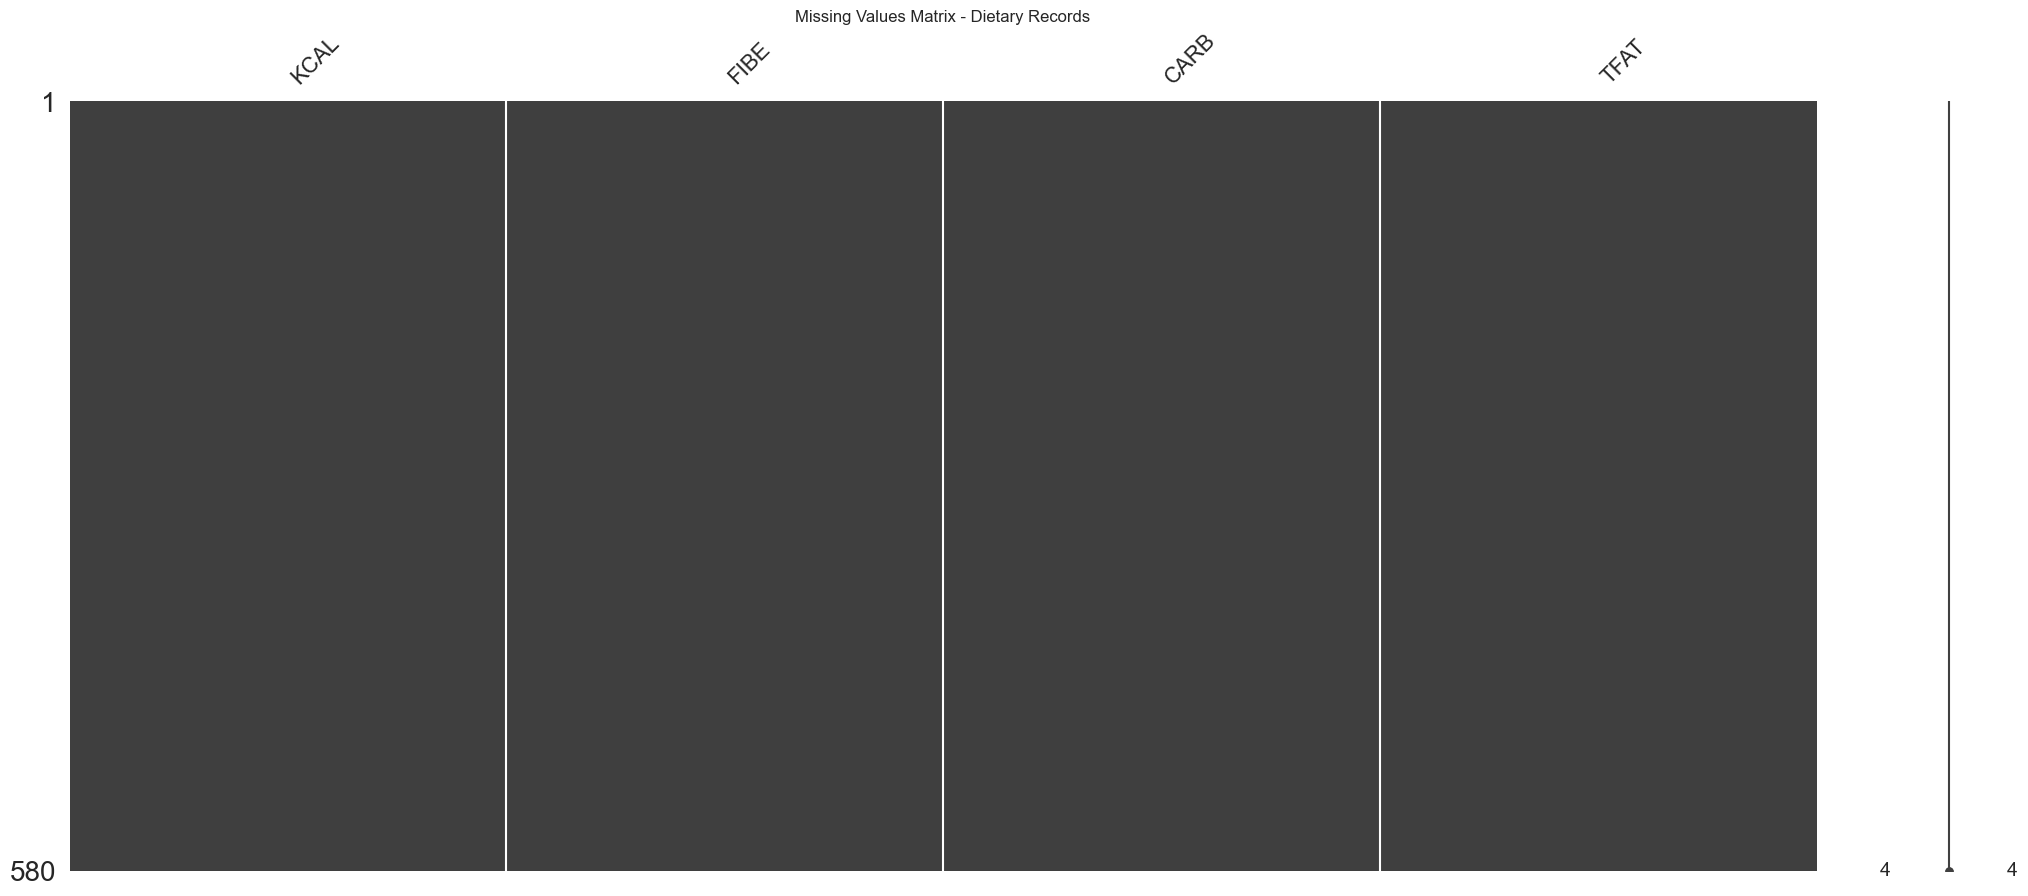

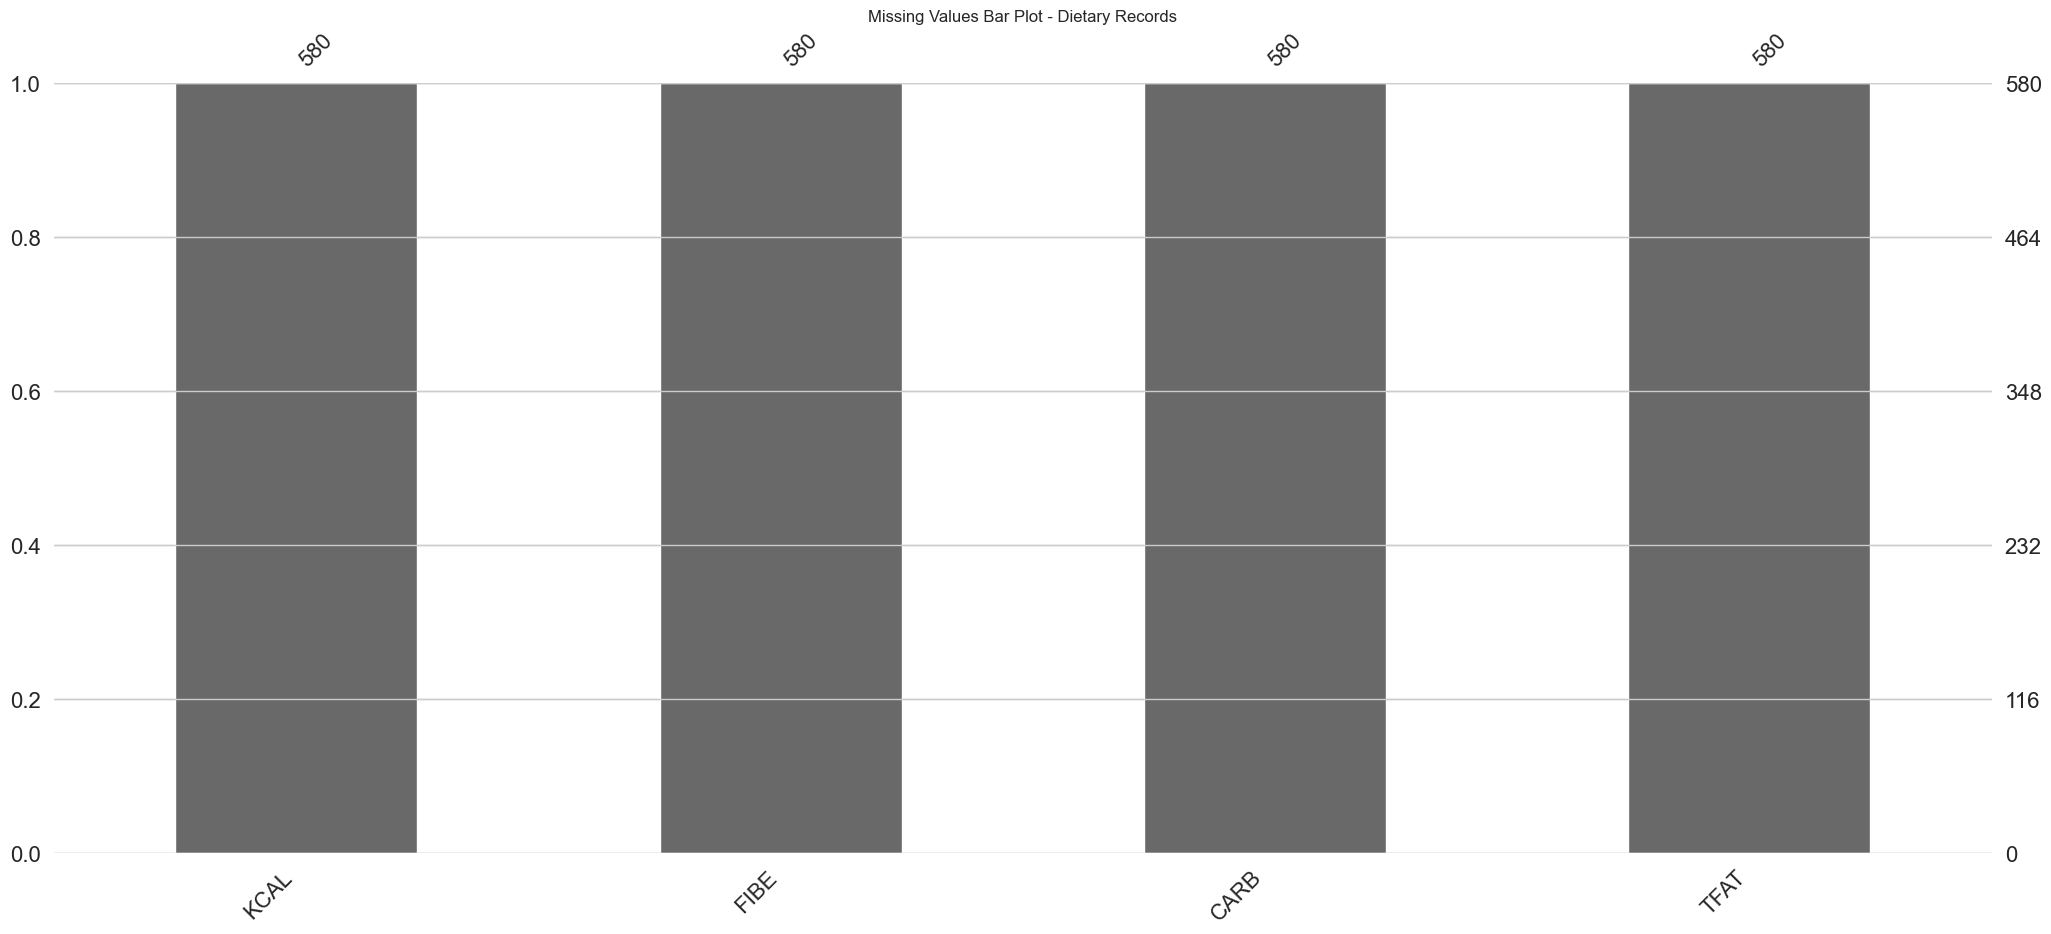

In [6]:
# Visualize missing data patterns

msno.matrix(df_nutrients[existing_nutrient_columns])
plt.title("Missing Values Matrix - Dietary Records")
plt.show()

msno.bar(df_nutrients[existing_nutrient_columns])
plt.title("Missing Values Bar Plot - Dietary Records")
plt.show()

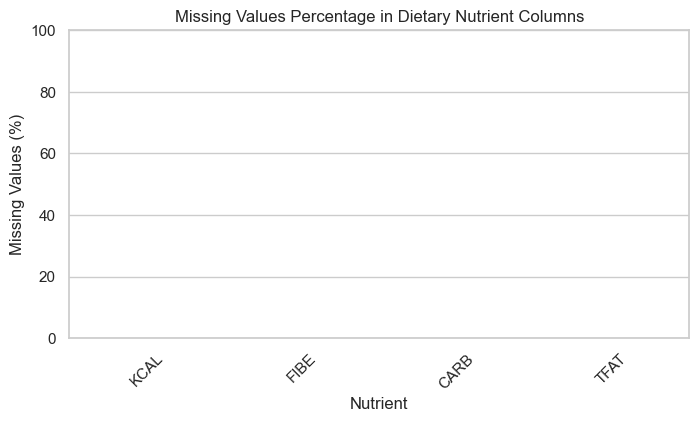

In [7]:
# Create a bar plot for missing percentages

plt.figure(figsize=(8, 4))
sns.barplot(data=missing_df, x="Feature", y="Missing Percentage")
plt.title("Missing Values Percentage in Dietary Nutrient Columns")
plt.xlabel("Nutrient")
plt.ylabel("Missing Values (%)")
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.show()

In [8]:
# Load participant metadata containing Age and BMI

df_metadata = pd.read_csv(metadata_path, sep="\t")
df_metadata.columns = df_metadata.columns.str.strip()

print("Metadata shape:", df_metadata.shape)
display(df_metadata.head())

print("Metadata columns:")
print(df_metadata.columns.tolist())

Metadata shape: (566, 29)


,#SampleID,UserName,StudyDayNo,StudyDate,Sample.Week.Day,DietDayNo,Diet.Record.Date,Diet.Week.Day,Gender,Age,...,BMI.1,Weight.Change,Run1.Plate,Run2.Rerun,SampleOrder,SampleType,Timing,Activity.Factor,Medications,Dietary.Supp
0,MCT.f.0001,MCTs01,1,1/31/17,Tuesday,0,1/30/17,Monday,F,25.9,...,25.0,-0.4,5.0,NaN,54.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
1,MCT.f.0002,MCTs01,2,2/1/17,Wednesday,1,1/31/17,Tuesday,F,25.9,...,25.0,-0.4,1.0,NaN,39.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
2,MCT.f.0003,MCTs01,3,2/2/17,Thursday,2,2/1/17,Wednesday,F,25.9,...,25.0,-0.4,1.0,NaN,59.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
3,MCT.f.0004,MCTs01,4,2/3/17,Friday,3,2/2/17,Thursday,F,25.9,...,25.0,-0.4,5.0,NaN,32.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
4,MCT.f.0005,MCTs01,5,2/4/17,Saturday,4,2/3/17,Friday,F,25.9,...,25.0,-0.4,2.0,Yes,89.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc


Metadata columns:
['#SampleID', 'UserName', 'StudyDayNo', 'StudyDate', 'Sample.Week.Day', 'DietDayNo', 'Diet.Record.Date', 'Diet.Week.Day', 'Gender', 'Age', 'Weight', 'Height', 'BMI', 'Supplement', 'Waist.Circumference', 'Study.Status', 'oilGrams.assigned', 'fecal.status', 'fecal.time', 'BMI.1', 'Weight.Change', 'Run1.Plate', 'Run2.Rerun', 'SampleOrder', 'SampleType', 'Timing', 'Activity.Factor', 'Medications', 'Dietary.Supp']


In [9]:
# Select participant-level metadata columns

profile_columns = ["Age", "BMI"]

df_profile = (
    df_metadata[["UserName"] + profile_columns]
    .drop_duplicates(subset="UserName")
    .copy()
)

print("Profile dataframe shape:", df_profile.shape)
display(df_profile.head())

print("Missing values in profile columns:")
display(df_profile[profile_columns].isnull().mean().mul(100))

Profile dataframe shape: (34, 3)


,UserName,Age,BMI
0,MCTs01,25.9,25.0
17,MCTs03,25.4,26.6
33,MCTs04,24.0,18.9
50,MCTs05,23.1,19.9
57,MCTs06,23.7,22.7


Missing values in profile columns:


Age    0.0
BMI    0.0
dtype: float64

In [10]:
# Aggregate daily dietary records into average nutrient intake per participant

df_dietary_analysis = (
    df_nutrients
    .groupby("UserName")[existing_nutrient_columns]
    .mean()
    .reset_index()
)

print("Dietary analysis shape:", df_dietary_analysis.shape)
display(df_dietary_analysis.head())

Dietary analysis shape: (37, 5)


,UserName,KCAL,FIBE,CARB,TFAT
0,MCTs01,2233.971687,23.530833,246.315305,72.793184
1,MCTs02,1406.094472,12.205770,102.572981,88.889560
2,MCTs03,3797.839598,32.528277,379.484855,179.378471
3,MCTs04,2554.895951,33.822869,259.635868,123.521241
4,MCTs05,1459.168123,13.046344,193.945721,51.869562


In [11]:
# Merge dietary averages with participant metadata

df_analysis_full = df_dietary_analysis.merge(
    df_profile,
    on="UserName",
    how="left"
)

print("Full analysis dataframe shape:", df_analysis_full.shape)
display(df_analysis_full.head())

print("Missing values after merge:")
display(df_analysis_full[existing_nutrient_columns + profile_columns].isnull().mean().mul(100))

Full analysis dataframe shape: (37, 7)


,UserName,KCAL,FIBE,CARB,TFAT,Age,BMI
0,MCTs01,2233.971687,23.530833,246.315305,72.793184,25.9,25.0
1,MCTs02,1406.094472,12.205770,102.572981,88.889560,NaN,NaN
2,MCTs03,3797.839598,32.528277,379.484855,179.378471,25.4,26.6
3,MCTs04,2554.895951,33.822869,259.635868,123.521241,24.0,18.9
4,MCTs05,1459.168123,13.046344,193.945721,51.869562,23.1,19.9


Missing values after merge:


KCAL    0.000000
FIBE    0.000000
CARB    0.000000
TFAT    0.000000
Age     8.108108
BMI     8.108108
dtype: float64

In [12]:
# Missing values summary after merging dietary records with participant metadata

missing_after_merge = (
    df_analysis_full[existing_nutrient_columns + profile_columns]
    .isnull()
    .sum()
    .reset_index()
)

missing_after_merge.columns = ["Feature", "Missing Count"]
missing_after_merge["Missing Percentage"] = (
    missing_after_merge["Missing Count"] / len(df_analysis_full) * 100
)

display(missing_after_merge)

,Feature,Missing Count,Missing Percentage
0,KCAL,0,0.000000
1,FIBE,0,0.000000
2,CARB,0,0.000000
3,TFAT,0,0.000000
4,Age,3,8.108108
5,BMI,3,8.108108


In [13]:
# Identify participants with dietary records but missing participant metadata

missing_profile_users = df_analysis_full[
    df_analysis_full["Age"].isna() | df_analysis_full["BMI"].isna()
]["UserName"].tolist()

print("Number of participants with missing Age/BMI:", len(missing_profile_users))
print("Participants with missing Age/BMI:")
print(missing_profile_users)

Number of participants with missing Age/BMI: 3
Participants with missing Age/BMI:
['MCTs02', 'MCTs17', 'MCTs30']


In [14]:
# Compare participants available in dietary records vs. participant metadata

diet_users = set(df_dietary_analysis["UserName"])
profile_users = set(df_profile["UserName"])

users_only_in_diet = sorted(diet_users - profile_users)
users_only_in_profile = sorted(profile_users - diet_users)

print("Number of participants in dietary records:", len(diet_users))
print("Number of participants in metadata:", len(profile_users))

print("\nParticipants found in dietary records but missing from metadata:")
print(users_only_in_diet)

print("\nParticipants found in metadata but missing from dietary records:")
print(users_only_in_profile)

Number of participants in dietary records: 37
Number of participants in metadata: 34

Participants found in dietary records but missing from metadata:
['MCTs02', 'MCTs17', 'MCTs30']

Participants found in metadata but missing from dietary records:
[]


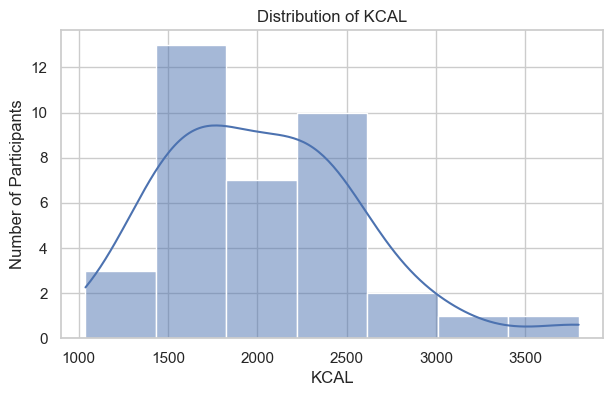

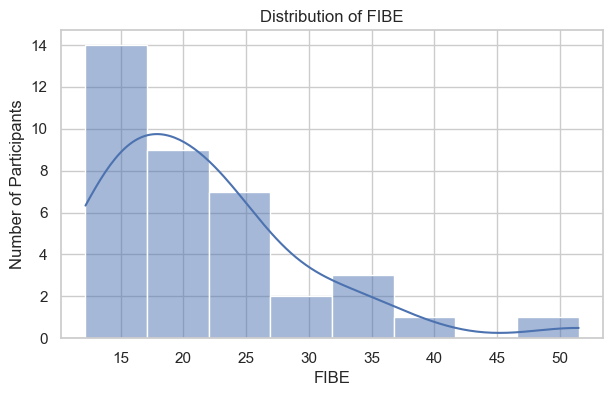

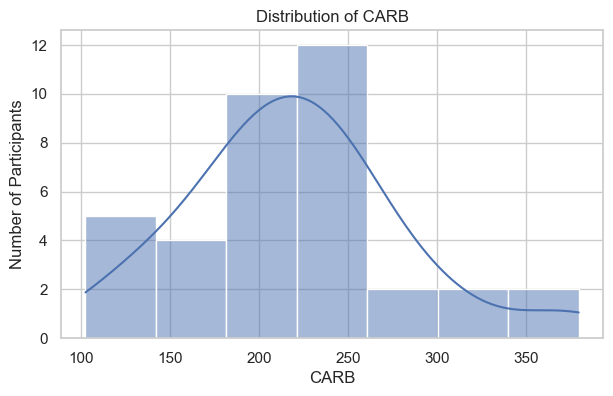

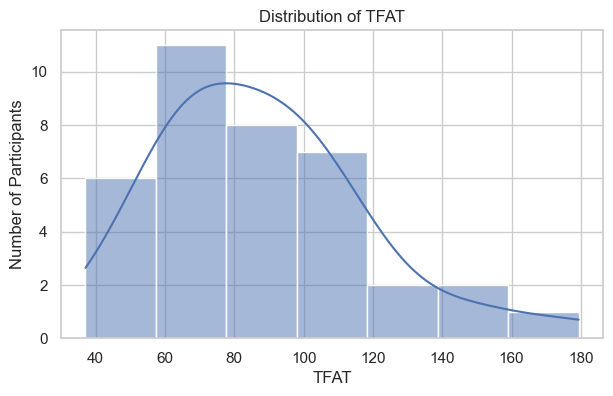

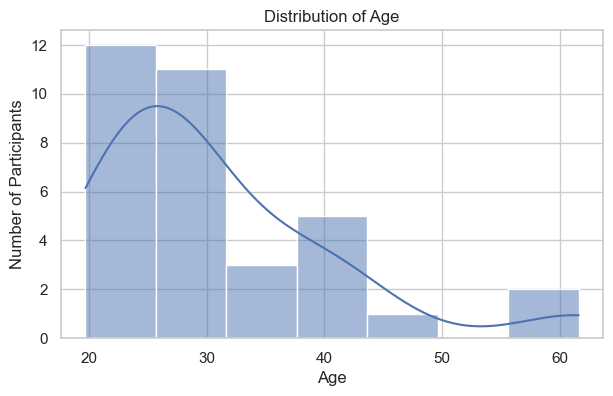

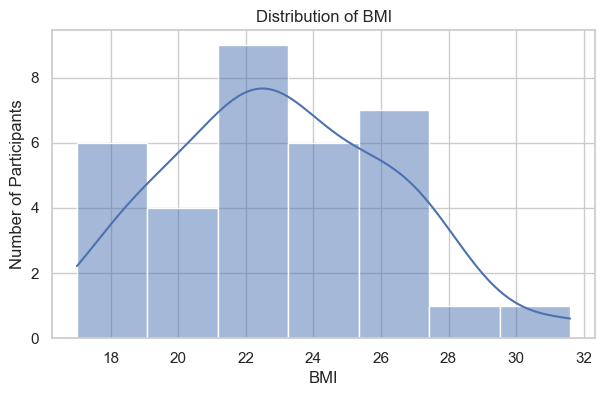

In [15]:
# Histograms for nutrient intake and participant characteristics

analysis_columns = existing_nutrient_columns + profile_columns

for col in analysis_columns:
    plt.figure(figsize=(7, 4))
    sns.histplot(df_analysis_full[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Participants")
    plt.show()

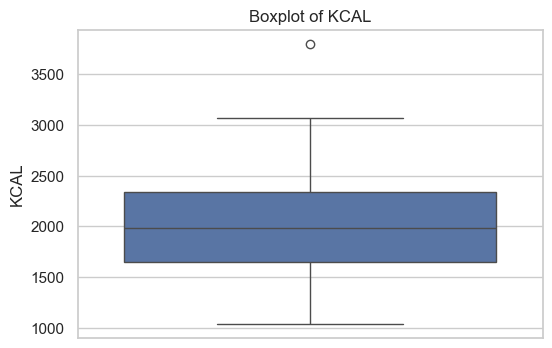

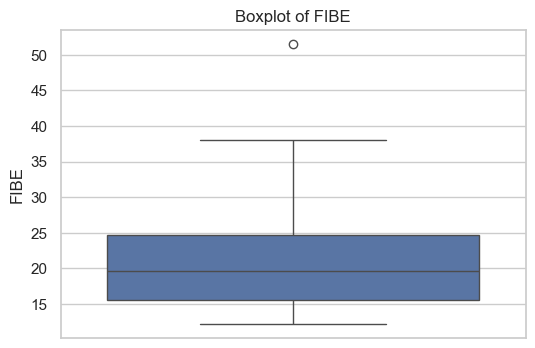

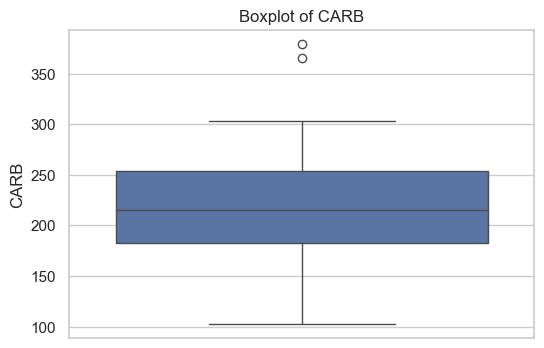

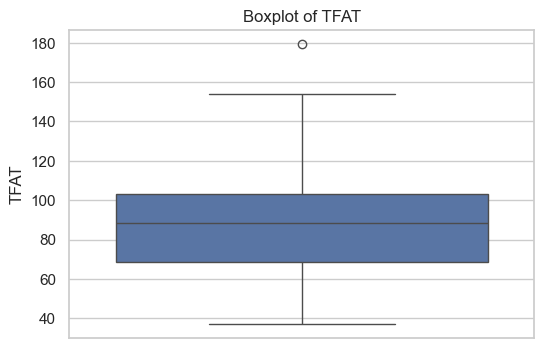

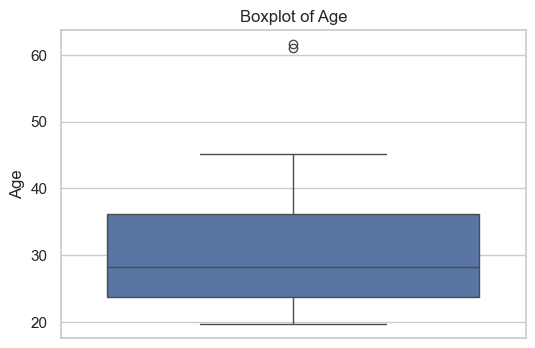

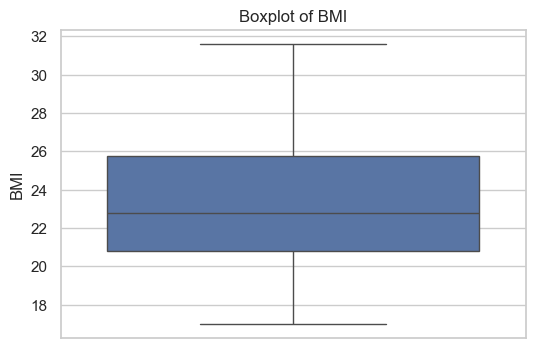

In [16]:
# Boxplots for nutrient intake and participant characteristics

for col in analysis_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df_analysis_full[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

In [17]:
# Create a complete-case dataset for analyses requiring participant metadata

df_analysis_complete = df_analysis_full.dropna(subset=["Age", "BMI"]).copy()

print("Original merged dataset shape:", df_analysis_full.shape)
print("Complete-case dataset shape:", df_analysis_complete.shape)

display(df_analysis_complete.head())

Original merged dataset shape: (37, 7)
Complete-case dataset shape: (34, 7)


,UserName,KCAL,FIBE,CARB,TFAT,Age,BMI
0,MCTs01,2233.971687,23.530833,246.315305,72.793184,25.9,25.0
2,MCTs03,3797.839598,32.528277,379.484855,179.378471,25.4,26.6
3,MCTs04,2554.895951,33.822869,259.635868,123.521241,24.0,18.9
4,MCTs05,1459.168123,13.046344,193.945721,51.869562,23.1,19.9
5,MCTs06,2821.157393,25.010255,300.566053,119.229383,23.7,22.7


In [18]:
# Descriptive statistics for dietary and participant-level variables

summary_stats = df_analysis_full[analysis_columns].describe().T
display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
KCAL,37.0,2033.297533,555.341419,1038.411469,1647.969946,1986.314418,2338.837036,3797.839598
FIBE,37.0,21.501996,8.227874,12.205770,15.555740,19.614496,24.741995,51.493771
CARB,37.0,219.889581,60.207579,102.572981,183.135589,215.304862,253.876709,379.484855
TFAT,37.0,88.114532,30.307293,37.064239,68.770390,88.392512,103.046069,179.378471
Age,34.0,30.823529,10.263264,19.700000,23.750000,28.200000,36.125000,61.600000
BMI,34.0,23.091176,3.315470,17.000000,20.800000,22.800000,25.750000,31.600000


In [19]:
# Descriptive statistics for dietary and participant-level variables without missing metadata


summary_stats = df_analysis_complete[analysis_columns].describe().T
display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
KCAL,34.0,2080.282967,554.371204,1038.411469,1720.475921,2053.170958,2381.937003,3797.839598
FIBE,34.0,21.914465,8.363119,12.578621,16.016949,20.144428,24.943190,51.493771
CARB,34.0,226.308557,57.376045,118.539338,194.193916,224.196062,255.340657,379.484855
TFAT,34.0,89.682832,30.884412,37.064239,69.391504,89.026639,105.218414,179.378471
Age,34.0,30.823529,10.263264,19.700000,23.750000,28.200000,36.125000,61.600000
BMI,34.0,23.091176,3.315470,17.000000,20.800000,22.800000,25.750000,31.600000


EDA on CFMD 

# CFMD Food Microbiome Analysis

**Data source:** CuratedFoodMetagenomicData (CFMD)
- `cFMD-main/cFMD-main/cFMD_metadata.tsv` — sample metadata with `category`, `sample_id`
- `cFMD-main/cFMD-main/cFMD_data/**/*_taxonomic_profiles.tsv` — per-dataset abundance matrices

**Tasks:**
1. Explore CFMD and analyze food microbial richness per category
2. Check species overlap between the top-2 richest categories

## Cell 1 — Setup and Metadata Loading

=== CFMD Metadata ===
Shape   : (3444, 32)
Columns : ['dataset_name', 'sample_id', 'macrocategory', 'category', 'type', 'subtype', 'commercial_name', 'fermented/non-fermented', 'country', 'sample_accession', 'run_accession', 'experiment_accession', 'study_accession', 'project_accession', 'database_origin', 'library_layout', 'sequencing_platform', 'DNA_extraction_kit', 'collection_date', 'n_of_bases', 'n_of_reads', 'min_read_len', 'median_read_len', 'mean_read_len', 'max_read_len', 'n_contigs', 'n_MAGs_MQ_prok', 'n_MAGs_HQ_prok', 'n_MAGs_MQ_euk', 'n_MAGs_HQ_euk', 'filtered', 'curator']

'category' — 15 unique values:
category
dairy                              2296
fermented_beverages                 435
fermented_meat                      157
meat                                119
fish                                 93
fermented_grains                     83
fermented_seeds                      65
fermented_fruits_and_vegetables      52
alcohol                              48
fruits_

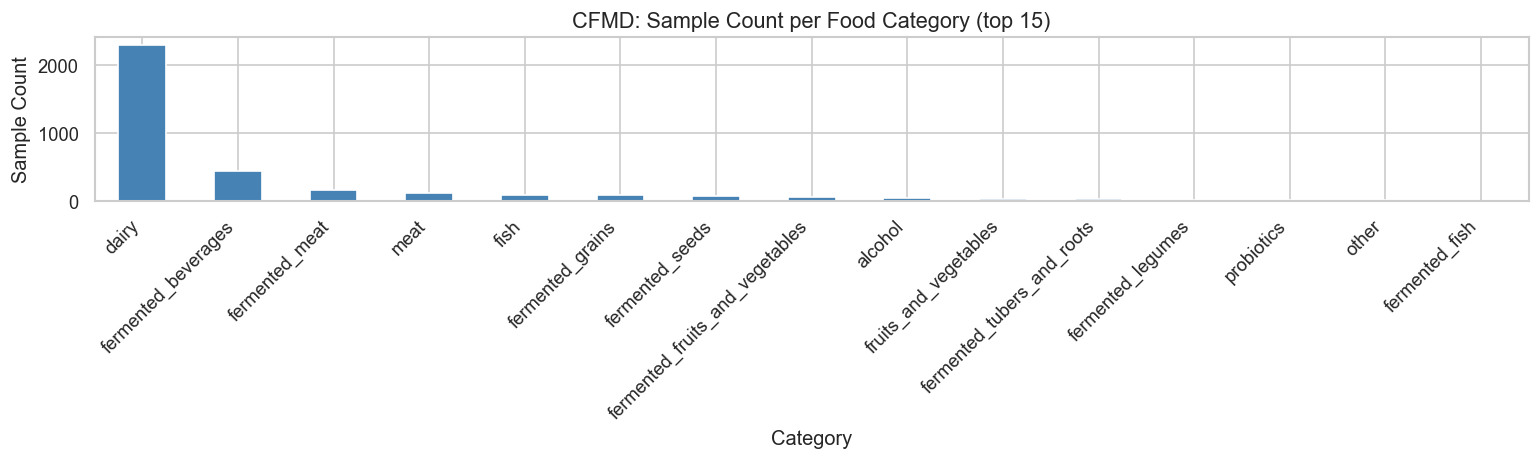

Plot saved → category_distribution.png

Macrocategory counts:
macrocategory
food    3444

Sequencing platform counts:
sequencing_platform
Illumina_NovaSeq_6000          1616
NextSeq_500                    1053
Illumina_MiSeq                  283
HiSeq X Ten                     119
Illumina_HiSeq_2500             102
Illumina_HiSeq_4000              75
NextSeq_550                      71
Illumina_HiSeq_2000              41
HiSeq_X_Ten                      20
Illumina_HiSeq_1500              15
Illumina_HiSeq_XTen              14
Illumina HiSeq 4000              13
Ion_Torrent_PGM                  10
Illumina NovaSeq 6000             4
Illumina MiSeq                    2
Illumina_Genome_Analyzer_II       2
Illumina_HiSeq_1000               2
Sequel;Illumina_MiSeq             1
Illumina HiSeq X                  1


In [20]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# ── Load metadata ─────────────────────────────────────────────────────────────
#metadata = pd.read_csv('./cFMD-main/cFMD-main/cFMD_metadata.tsv', sep='\t')
metadata = pd.read_csv('./data/cFMD-main/cFMD-main/cFMD_metadata.tsv', sep='\t')
metadata.columns = metadata.columns.astype(str).str.strip()
metadata['sample_id'] = metadata['sample_id'].astype(str).str.strip()

print('=== CFMD Metadata ===')
print(f'Shape   : {metadata.shape}')
print(f'Columns : {metadata.columns.tolist()}')
print()

# ── EDA: category distribution ────────────────────────────────────────────────
cat_counts = metadata['category'].value_counts()
print(f"'category' — {cat_counts.shape[0]} unique values:")
print(cat_counts.to_string())

fig, ax = plt.subplots(figsize=(13, 4))
cat_counts.head(15).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('CFMD: Sample Count per Food Category (top 15)', fontsize=13)
ax.set_xlabel('Category')
ax.set_ylabel('Sample Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → category_distribution.png')

# ── EDA: macrocategory distribution ──────────────────────────────────────────
print()
print('Macrocategory counts:')
print(metadata['macrocategory'].value_counts().to_string())

# ── EDA: sequencing platform ──────────────────────────────────────────────────
print()
print('Sequencing platform counts:')
print(metadata['sequencing_platform'].value_counts().to_string())

## Cell 2 — Load Taxonomic Profiles and Merge with Metadata

Each `*_taxonomic_profiles.tsv` file is a wide matrix: rows = taxa, columns = samples.
Column names are formatted as `DatasetName__SampleAccession`.
We extract the accession part (after `__`) to match `sample_id` in the metadata.

In [21]:
# profile_files = glob.glob(
#     './cFMD-main/cFMD-main/cFMD_data/**/*_taxonomic_profiles.tsv',
#     recursive=True
# )
profile_files = glob.glob(
    './data/cFMD-main/cFMD-main/cFMD_data/**/*_taxonomic_profiles.tsv',
    recursive=True
)
print(f'Found {len(profile_files)} taxonomic profile files')

all_profiles = []
skipped = []

for path in profile_files:
    try:
        df = pd.read_csv(path, sep='\t')
        # First column is always the taxonomy column
        tax_col = df.columns[0]
        df = df.rename(columns={tax_col: '#taxonomy'})

        # Melt wide → long
        long = df.melt(
            id_vars=['#taxonomy'],
            var_name='sample_col',
            value_name='abundance'
        )

        # Column names: 'DatasetName__SampleAccession' → extract accession after '__'
        long['sample_id'] = long['sample_col'].str.split('__').str[-1]
        long = long.drop(columns=['sample_col'])
        all_profiles.append(long)

    except Exception as e:
        skipped.append((path, str(e)))

if skipped:
    print(f'\nSkipped {len(skipped)} files:')
    for p, e in skipped:
        print(f'  {p}: {e}')

# Combine all datasets
long_df = pd.concat(all_profiles, ignore_index=True)
long_df['sample_id'] = long_df['sample_id'].astype(str).str.strip()
long_df['abundance'] = pd.to_numeric(long_df['abundance'], errors='coerce').fillna(0)

print(f'\nCombined long-format shape : {long_df.shape}')
print(f'Unique sample IDs in profiles : {long_df["sample_id"].nunique()}')
print(f'Unique taxa in profiles       : {long_df["#taxonomy"].nunique()}')


# ── Merge with metadata ───────────────────────────────────────────────────────
merged = long_df.merge(
    metadata[['sample_id', 'category', 'macrocategory', 'country', 'fermented/non-fermented']],
    on='sample_id',
    how='left'
)

# Filter: keep only rows with positive abundance
merged_filtered = merged[merged['abundance'] > 0].copy()

print(f'\nRows after filtering (abundance > 0) : {len(merged_filtered):,}')
print(f'Unique taxa retained                 : {merged_filtered["#taxonomy"].nunique()}')
print(f'Missing category (unmatched samples) : {merged_filtered["category"].isna().sum():,}')
print(f'Categories present                   : {merged_filtered["category"].nunique()}')
print()
print('Sample category distribution:')
print(merged_filtered.dropna(subset=['category'])["category"].value_counts().to_string())

display(merged_filtered.head())

Found 85 taxonomic profile files

Combined long-format shape : (1614609, 3)
Unique sample IDs in profiles : 3392
Unique taxa in profiles       : 5057

Rows after filtering (abundance > 0) : 94,491
Unique taxa retained                 : 5051
Missing category (unmatched samples) : 0
Categories present                   : 15

Sample category distribution:
category
dairy                              57653
fermented_beverages                 7663
fermented_meat                      5649
meat                                4976
fish                                4558
fermented_seeds                     4537
fruits_and_vegetables               2883
fermented_fruits_and_vegetables     1637
fermented_tubers_and_roots          1465
fermented_grains                    1161
alcohol                              944
fermented_legumes                    936
other                                223
probiotics                           114
fermented_fish                        92


,#taxonomy,abundance,sample_id,category,macrocategory,country,fermented/non-fermented
0,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactob...,0.14109,SRR8742576,fermented_seeds,food,BRA,F
3,k__Bacteria|p__Pseudomonadota|c__Gammaproteoba...,0.10390,SRR8742576,fermented_seeds,food,BRA,F
7,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactob...,14.74891,SRR8742576,fermented_seeds,food,BRA,F
12,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactob...,0.33599,SRR8742576,fermented_seeds,food,BRA,F
20,k__Eukaryota|p__Ascomycota|c__Saccharomycetes|...,0.89747,SRR8742576,fermented_seeds,food,BRA,F


## Cell 3 — Task 1: Microbial Richness per Food Category

**Richness** = number of unique taxa with abundance > 0 per food category.

=== Microbial Richness per Food Category ===
                       category  microbial_richness
                          dairy                2967
                 fermented_meat                 854
          fruits_and_vegetables                 823
            fermented_beverages                 751
                fermented_seeds                 718
     fermented_tubers_and_roots                 699
fermented_fruits_and_vegetables                 529
                           fish                 490
                           meat                 380
              fermented_legumes                 368
               fermented_grains                 361
                        alcohol                 330
                          other                 158
                 fermented_fish                  44
                     probiotics                  36


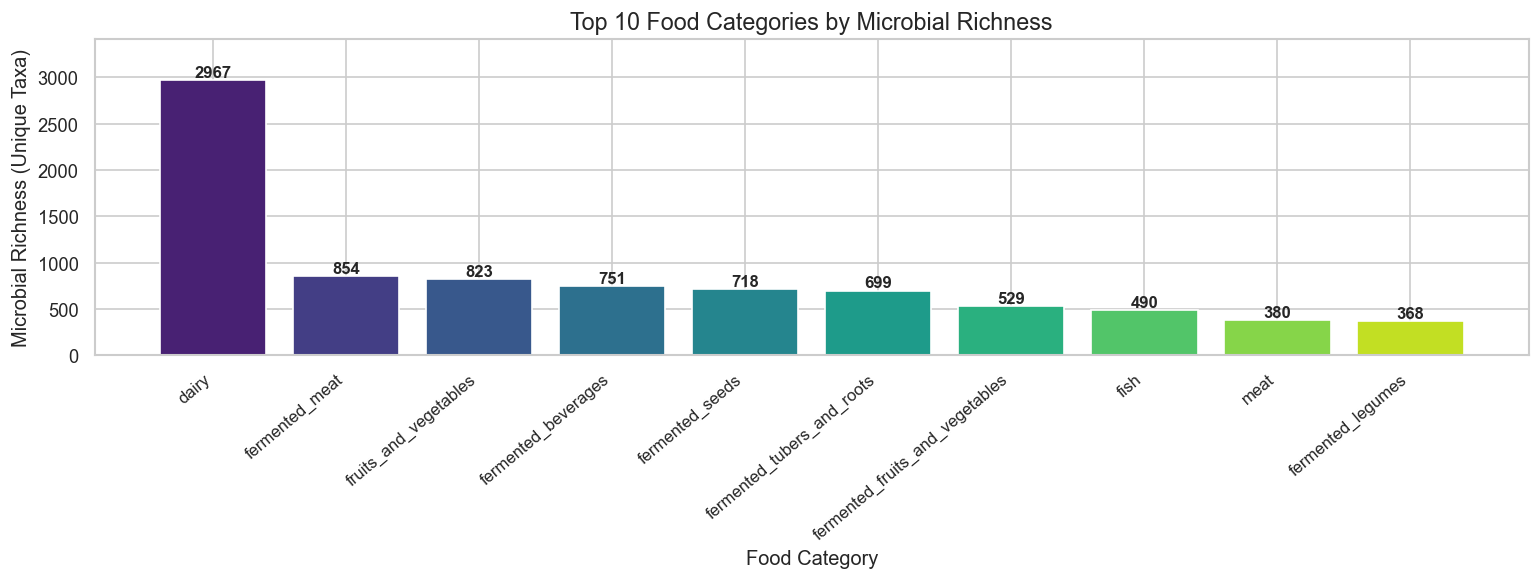

Plot saved → richness_by_category.png


In [22]:
# Guard: verify merge succeeded
if 'category' not in merged_filtered.columns or merged_filtered['category'].isna().all():
    raise RuntimeError('category data is missing — merge did not succeed. Fix Cell 2.')

richness = (
    merged_filtered
    .dropna(subset=['category'])
    .groupby('category')['#taxonomy']
    .nunique()
    .reset_index(name='microbial_richness')
    .sort_values('microbial_richness', ascending=False)
    .reset_index(drop=True)
)

print('=== Microbial Richness per Food Category ===')
print(richness.to_string(index=False))

# ── Bar chart: top 10 ─────────────────────────────────────────────────────────
top10   = richness.head(10)
palette = sns.color_palette('viridis', len(top10))

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(
    top10['category'],
    top10['microbial_richness'],
    color=palette,
    edgecolor='white'
)
for bar, val in zip(bars, top10['microbial_richness']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        str(int(val)),
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Top 10 Food Categories by Microbial Richness', fontsize=14)
ax.set_xlabel('Food Category', fontsize=12)
ax.set_ylabel('Microbial Richness (Unique Taxa)', fontsize=12)
ax.set_ylim(0, top10['microbial_richness'].max() * 1.15)
plt.xticks(rotation=40, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig('richness_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → richness_by_category.png')

## Cell 4 — Task 2: Species Overlap between Top-2 Categories (Venn Diagram)

We compare the two richest food categories using a Venn diagram and the Jaccard similarity index.

Comparing: 'dairy'  vs  'fermented_meat'

Species unique to 'dairy'  : 2,346
Species unique to 'fermented_meat'  : 233
Shared species              : 621
Jaccard similarity index    : 0.1941

Top shared species (last taxonomic level):
  t__SGB257
  t__SGB203
  t__SGB282
  t__SGB39400
  t__SGB33761
  t__SGB23979
  t__SGB98684
  t__SGB86828
  t__SGB17183
  t__SGB17232
  t__SGB93302
  t__SGB98927
  t__SGB99001
  t__SGB99002
  t__SGB16645
  t__SGB98807
  t__SGB16638
  t__SGB98794
  t__SGB16639
  t__SGB88049
  ... and 601 more


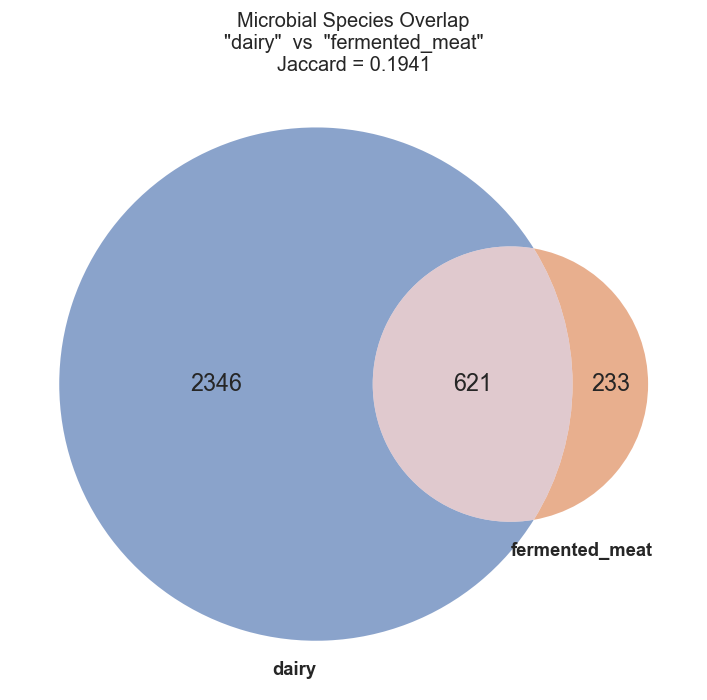

Plot saved → venn_species_overlap.png


In [23]:
try:
    from matplotlib_venn import venn2
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'matplotlib-venn', '-q'])
    from matplotlib_venn import venn2

cat1, cat2 = richness.head(2)['category'].tolist()
print(f"Comparing: '{cat1}'  vs  '{cat2}'")

sp1    = set(merged_filtered.loc[merged_filtered['category'] == cat1, '#taxonomy'].unique())
sp2    = set(merged_filtered.loc[merged_filtered['category'] == cat2, '#taxonomy'].unique())
shared = sp1 & sp2
union  = sp1 | sp2

print(f"\nSpecies unique to '{cat1}'  : {len(sp1 - sp2):,}")
print(f"Species unique to '{cat2}'  : {len(sp2 - sp1):,}")
print(f"Shared species              : {len(shared):,}")
print(f"Jaccard similarity index    : {len(shared) / len(union):.4f}")

if shared:
    print(f'\nTop shared species (last taxonomic level):')
    for s in sorted(shared)[:20]:  # show first 20
        sep   = '|' if '|' in s else ';'
        label = s.split(sep)[-1].strip()
        print(f'  {label}')
    if len(shared) > 20:
        print(f'  ... and {len(shared) - 20} more')

# ── Venn diagram ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
v = venn2(
    subsets=[sp1, sp2],
    set_labels=(cat1, cat2),
    ax=ax,
    set_colors=('#4C72B0', '#DD8452'),
    alpha=0.65
)
for region_id in ('10', '01', '11'):
    lbl = v.get_label_by_id(region_id)
    if lbl:
        lbl.set_fontsize(14)
for set_lbl in v.set_labels:
    if set_lbl:
        set_lbl.set_fontsize(11)
        set_lbl.set_fontweight('bold')

ax.set_title(
    f'Microbial Species Overlap\n"{cat1}"  vs  "{cat2}"\nJaccard = {len(shared)/len(union):.4f}',
    fontsize=12
)
plt.tight_layout()
plt.savefig('venn_species_overlap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → venn_species_overlap.png')

# Loading and Exploring the Paper 1 Microbiome Dataset

In [24]:
import pandas as pd
import os

#base = r"C:\Users\rtajz\Downloads\dietstudy_analyses-master\dietstudy_analyses-master\data"
base = str(Path.cwd()) + "\data\dietstudy_analyses-master\data"

print(base)
print("Base exists:", os.path.exists(base))

microbiome = pd.read_csv(
    f"{base}/microbiome/processed_sample/taxonomy_counts_s.txt",
    sep="\t",
    index_col=0
)

sample_meta = pd.read_csv(
    f"{base}/maps/food_map.txt",
    sep="\t"
).rename(columns={"#SampleID": "SampleID"})

diet_raw = pd.read_csv(
    f"{base}/diet/processed_food/dhydrt.txt",
    sep="\t",
    index_col=0
)

diet_decay = pd.read_csv(
    f"{base}/diet/processed_food/masterdecaydiet.txt",
    sep="\t",
    index_col=0
)

nutrition_totals = pd.read_csv(
    f"{base}/diet/nutrition_totals.txt",
    sep="\t",
    index_col=0
)

microbiome_clr = pd.read_csv(
    f"{base}/microbiome/processed_sample/taxonomy_clr_s.txt",
    sep="\t",
    index_col=0
)

diet_fiber = pd.read_csv(
    f"{base}/diet/diet.fiber.txt",
    sep="\t",
    index_col=0
)

fiber_avg = pd.read_csv(
    f"{base}/diet/fiber/fiber.smry.otu.txt",
    sep="\t",
    index_col=0
)

micro_avg_counts = pd.read_csv(
    f"{base}/microbiome/processed_average/UN_taxonomy_counts_s.txt",
    sep="\t",
    index_col=0
)

micro_avg_clr = pd.read_csv(
    f"{base}/microbiome/processed_average/UN_taxonomy_clr_s.txt",
    sep="\t",
    index_col=0
)

micro_avg_norm = pd.read_csv(
    f"{base}/microbiome/processed_average/UN_taxonomy_norm_s.txt",
    sep="\t",
    index_col=0
)

print("=== microbiome ===")
print(microbiome.shape)
print(microbiome.head())

print("=== sample_meta ===")
print(sample_meta.shape)
print(sample_meta.head())

print("=== diet_raw ===")
print(diet_raw.shape)
print(diet_raw.head())

print("=== diet_decay ===")
print(diet_decay.shape)
print(diet_decay.head())

print("=== nutrition_totals ===")
print(nutrition_totals.shape)
print(nutrition_totals.head())

print("=== microbiome_clr ===")
print(microbiome_clr.shape)
print(microbiome_clr.head())

print("=== diet_fiber ===")
print(diet_fiber.shape)
print(diet_fiber.head())

print("=== fiber_avg ===")
print(fiber_avg.shape)
print(fiber_avg.head())

print("=== micro_avg_counts ===")
print(micro_avg_counts.shape)
print(micro_avg_counts.head())

print("=== micro_avg_clr ===")
print(micro_avg_clr.shape)
print(micro_avg_clr.head())

print("=== micro_avg_norm ===")
print(micro_avg_norm.shape)
print(micro_avg_norm.head())

microbiome.to_csv("microbiome.csv")
sample_meta.to_csv("sample_meta.csv", index=False)
diet_raw.to_csv("diet_raw.csv")
diet_decay.to_csv("diet_decay.csv")
nutrition_totals.to_csv("nutrition_totals.csv")
microbiome_clr.to_csv("microbiome_clr.csv")
diet_fiber.to_csv("diet_fiber.csv")
fiber_avg.to_csv("fiber_avg.csv")
micro_avg_counts.to_csv("micro_avg_counts.csv")
micro_avg_clr.to_csv("micro_avg_clr.csv")
micro_avg_norm.to_csv("micro_avg_norm.csv")

print("Done! CSV files were saved.")

c:\Users\ayele\OneDrive\Desktop\year 3\project\data\dietstudy_analyses-master\data
Base exists: True
=== microbiome ===
(223, 483)
                                                    MCT.f.0002  MCT.f.0003  \
#taxonomy                                                                    
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__...       79055       33364   
k__Bacteria;p__Firmicutes;c__Clostridia;o__Clos...        2421       16944   
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__...       39779        9983   
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__...           1           5   
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__...       18393         561   

                                                    MCT.f.0004  MCT.f.0005  \
#taxonomy                                                                    
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__...       64027       70720   
k__Bacteria;p__Firmicutes;c__Clostridia;o__Clos...       43511       18335   
k__Bacteri

PermissionError: [Errno 13] Permission denied: 'diet_fiber.csv'

# Profiling the Paper 1 Gut Microbiome Abundance Dataset

In [ ]:
import pandas as pd
import numpy as np

microbiome = pd.read_csv("microbiome.csv", index_col=0)

print("Shape:", microbiome.shape)
print("Number of microbial features:", microbiome.shape[0])
print("Number of samples:", microbiome.shape[1])

print("\nFirst rows:")
display(microbiome.head())

print("\nBasic statistics:")
display(microbiome.describe())

Shape: (223, 483)
Number of microbial features: 223
Number of samples: 483

First rows:


,MCT.f.0002,MCT.f.0003,MCT.f.0004,MCT.f.0005,MCT.f.0006,MCT.f.0007,MCT.f.0008,MCT.f.0009,MCT.f.0010,MCT.f.0011,...,MCT.f.0618,MCT.f.0619,MCT.f.0620,MCT.f.0621,MCT.f.0622,MCT.f.0623,MCT.f.0624,MCT.f.0625,MCT.f.0627,MCT.f.0628
#taxonomy,,,,,,,,,,,,,,,,,,,,,
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides;NA,79055,33364,64027,70720,63361,58636,73520,69225,58080,75592,...,116037,93723,105413,100387,97278,117400,123705,96470,117867,93290
k__Bacteria;p__Firmicutes;c__Clostridia;o__Clostridiales;f__Ruminococcaceae;g__Faecalibacterium;s__Faecalibacterium prausnitzii,2421,16944,43511,18335,36493,43987,15944,20583,5493,23064,...,11,62,3,5,23,2,7,18,2206,5
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides;s__Bacteroides uniformis,39779,9983,31539,44880,29901,31975,41607,39981,32774,41183,...,25278,26608,24590,26421,24128,23532,20010,22195,9340,21397
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Prevotellaceae;g__Prevotella;s__Prevotella copri,1,5,4,4,7,2,13,3,9,4,...,7,10,1,0,184,2,2,6,142,1
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Rikenellaceae;g__Alistipes;s__Alistipes putredinis,18393,561,11742,15831,14319,16541,8328,10082,40723,16670,...,11,52,6,9,13,5,10,9,1246,4



Basic statistics:


,MCT.f.0002,MCT.f.0003,MCT.f.0004,MCT.f.0005,MCT.f.0006,MCT.f.0007,MCT.f.0008,MCT.f.0009,MCT.f.0010,MCT.f.0011,...,MCT.f.0618,MCT.f.0619,MCT.f.0620,MCT.f.0621,MCT.f.0622,MCT.f.0623,MCT.f.0624,MCT.f.0625,MCT.f.0627,MCT.f.0628
count,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000,...,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000
mean,1196.116592,1196.130045,1196.143498,1196.085202,1196.107623,1196.098655,1196.098655,1196.121076,1196.116592,1196.076233,...,1196.085202,1196.107623,1196.125561,1196.134529,1196.161435,1196.071749,1196.139013,1196.147982,1196.107623,1196.076233
std,6292.628430,3929.367321,5764.614294,6018.009459,5532.632866,5599.856620,5909.878262,5687.239997,5478.451081,6156.212415,...,9425.191368,9155.216598,9278.133530,8784.064237,9080.516936,9225.165606,9218.804988,8983.242874,8727.492092,9334.324673
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11.000000,13.000000,18.000000,15.000000,18.000000,16.000000,18.000000,21.000000,12.000000,13.500000,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,2.000000,7.000000,1.000000
50%,40.000000,91.000000,53.000000,57.000000,62.000000,53.000000,56.000000,55.000000,46.000000,44.000000,...,8.000000,10.000000,6.000000,7.000000,9.000000,7.000000,8.000000,11.000000,31.000000,6.000000
75%,145.500000,429.000000,231.500000,267.000000,224.500000,221.000000,285.000000,272.500000,141.500000,162.500000,...,63.500000,77.500000,87.500000,85.500000,76.000000,70.000000,85.500000,80.000000,174.500000,70.500000
max,79055.000000,33364.000000,64027.000000,70720.000000,63361.000000,58636.000000,73520.000000,69225.000000,58080.000000,75592.000000,...,116037.000000,96191.000000,105413.000000,100387.000000,97278.000000,117400.000000,123705.000000,96470.000000,117867.000000,101379.000000


EDA on microbiome data from the Johnson et al. 2019 research

## Gut Microbiome Data Profiling

In this step, we loaded the gut microbiome abundance table (`microbiome.csv`) generated from the Johnson et al. 2019 dataset.

We performed an initial profiling of the dataset to better understand its structure and characteristics before preprocessing and filtering.

### What we examined
- Dataset dimensions
- Number of microbial features (taxa/species)
- Number of samples
- First rows of the abundance table
- Descriptive statistics for abundance values

### Results
- The dataset contains:
  - **223 microbial features**
  - **483 fecal samples**
- Rows represent microbial taxa/species.
- Columns represent individual microbiome samples.
- The abundance values are highly variable across samples, with many low values and zeros, which is common in microbiome datasets.

### Key observations
- Some bacterial species are highly abundant in specific samples.
- Many taxa appear at very low abundance levels.
- The dataset is expected to be sparse, meaning many entries contain zeros due to absent or rare microbes.

This profiling step provides the foundation for the next stages:
1. Low-prevalence feature filtering
2. Sparsity analysis
3. Data preprocessing for downstream microbiome analysis

# Analyzing Sparsity and Feature Prevalence 

In [ ]:
# Calculate sparsity (percentage of zeros)

total_values = microbiome.size
zero_values = (microbiome == 0).sum().sum()

sparsity = (zero_values / total_values) * 100

print("Total values in dataset:", total_values)
print("Number of zero values:", zero_values)
print(f"Sparsity: {sparsity:.2f}%")

Total values in dataset: 107709
Number of zero values: 9467
Sparsity: 8.79%


In [ ]:
# Prevalence of each microbial feature
# (fraction of samples where feature appears)

prevalence = (microbiome > 0).sum(axis=1) / microbiome.shape[1]

print(prevalence.describe())

# Show first prevalence values
display(prevalence.head())

count    223.000000
mean       0.912106
std        0.145638
min        0.271222
25%        0.910973
50%        0.973085
75%        0.994824
max        1.000000
dtype: float64


#taxonomy
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides;NA                                   1.000000
k__Bacteria;p__Firmicutes;c__Clostridia;o__Clostridiales;f__Ruminococcaceae;g__Faecalibacterium;s__Faecalibacterium prausnitzii    1.000000
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides;s__Bacteroides uniformis             1.000000
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Prevotellaceae;g__Prevotella;s__Prevotella copri                   0.910973
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Rikenellaceae;g__Alistipes;s__Alistipes putredinis                 0.993789
dtype: float64

## Sparsity and Prevalence Analysis

In this step, we analyzed the sparsity and prevalence of the gut microbiome abundance table.

### Sparsity Analysis
We calculated the percentage of zero values in the dataset to measure sparsity.

### Results
- Total values in the dataset: **107,709**
- Zero values: **9,467**
- Dataset sparsity: **8.79%**

This indicates that most microbial features are present in many samples, while a smaller portion of the matrix contains absent microbes (zeros).

### Prevalence Analysis
We then calculated the prevalence of each microbial feature, defined as the fraction of samples in which a feature appears.

### Key observations
- The average prevalence across taxa is very high (~0.91).
- Many microbial species appear in nearly all samples.
- Some taxa are less common and appear only in a subset of participants.
- The minimum prevalence observed was approximately **27%** of samples.

These results suggest that the dataset is relatively dense compared to many microbiome datasets, but still contains lower-prevalence taxa that may be filtered in the next preprocessing stage.

# Filtering Low-Prevalence Microbial Features

In [ ]:
# Filter low-prevalence microbial features

threshold = 0.10   # keep taxa appearing in at least 10% of samples

filtered_microbiome = microbiome.loc[prevalence >= threshold]

print("Original shape:", microbiome.shape)
print("Filtered shape:", filtered_microbiome.shape)

print("Removed features:", microbiome.shape[0] - filtered_microbiome.shape[0])

Original shape: (223, 483)
Filtered shape: (223, 483)
Removed features: 0


In [ ]:
filtered_microbiome.to_csv("microbiome_filtered.csv")

print("Filtered microbiome dataset saved.")

Filtered microbiome dataset saved.


In [ ]:
import pandas as pd
import os

"""
paper2_data.py
Loads and exports datasets from Carlino et al. 2024 (Cell)
Source: https://github.com/SegataLab/cFMD
"""

# Base link to database
#base_cfmd = "cFMD/cFMD_data"
base_cfmd = r"data\cFMD-main\cFMD-main\cFMD_data"

# Dataset of microbial species  vs fecal samples
data_base = []
# Iterate on each dataset in the database
for dataset in os.listdir(base_cfmd):
    # Create path to dataset
    path = os.path.join(base_cfmd, dataset, f"{dataset}_taxonomic_profiles.tsv")
    # If the path is correct add the dataset to the data base
    if os.path.exists(path):
        df = pd.read_csv(path, sep="\t", index_col=0)
        data_base.append(df)

# Join the data sets to one single data set
combined = pd.concat(data_base, axis=1)
# Fill null value with zero
combined = combined.fillna(0)
print("Shape:", combined.shape)

# save the combined datasets to csv
combined.to_csv("combined_datasets.csv")

# Metadata on the microbiome
#metadata = pd.read_csv("cFMD/cFMD_metadata.tsv", sep="\t")
metadata = pd.read_csv("data/cFMD-main/cFMD-main/cFMD_metadata.tsv", sep="\t")
# Export the metadata to csv
metadata.to_csv("cfmd_metadata.csv", index=False)

Shape: (5057, 3393)


In [ ]:
import os

#for item in os.listdir(r"C:\Users\rtajz\Downloads"):
for item in os.listdir(r"data"):
    if "cFMD" in item or "cfmd" in item:
        print(item)

cFMD-main
cfmd_metadata.csv


# Loading and Combining the Paper 2 (cFMD) Microbiome Dataset

In [ ]:
import pandas as pd
import os

# Paper 2: Carlino et al. 2024 / cFMD dataset
#base_cfmd = r"C:\Users\rtajz\Downloads\cFMD-main\cFMD-main\cFMD_data"
#metadata_path = r"C:\Users\rtajz\Downloads\cFMD-main\cFMD-main\cFMD_metadata.tsv"
base_cfmd = r"data\cFMD-main\cFMD-main\cFMD_data"
metadata_path = r"data\cFMD-main\cFMD-main\cFMD_metadata.tsv"#

print("Base exists:", os.path.exists(base_cfmd))
print("Metadata exists:", os.path.exists(metadata_path))

data_base = []

for dataset in os.listdir(base_cfmd):
    path = os.path.join(base_cfmd, dataset, f"{dataset}_taxonomic_profiles.tsv")
    
    if os.path.exists(path):
        df = pd.read_csv(path, sep="\t", index_col=0)
        data_base.append(df)

combined = pd.concat(data_base, axis=1)
combined = combined.fillna(0)

print("=== Paper 2 combined dataset ===")
print("Shape:", combined.shape)
display(combined.head())

combined.to_csv("combined_datasets.csv")

metadata = pd.read_csv(metadata_path, sep="\t")

print("=== Paper 2 metadata ===")
print("Shape:", metadata.shape)
display(metadata.head())

metadata.to_csv("cfmd_metadata.csv", index=False)

print("Done! Paper 2 CSV files were saved.")

Base exists: True
Metadata exists: True
=== Paper 2 combined dataset ===
Shape: (5057, 3393)


,AlmeidaO_2020__SRR8742576,AlmeidaO_2020__SRR8742577,AlmeidaO_2020__SRR8742578,AlmeidaO_2020__SRR8742579,AlmeidaO_2020__SRR8742580,AlmeidaO_2020__SRR8742581,AlmeidaO_2020__SRR8742582,AlmeidaO_2020__SRR8742584,AlmeidaO_2020__SRR8742585,AlvarezOrdonezA_xxxx__C01-19,...,YuY_2022__SRR16950700,YuY_2022__SRR16950701,YuY_2022__SRR16950702,YuY_2022__SRR16950703,YuY_2022__SRR16950704,ZhaoCC_2020__SRS5803191,ZhaoCC_2020__SRS5803192,ZhaoCC_2020__SRS5803193,ZhaoCC_2020__SRS5803194,ZhaoCC_2020__SRS5803195
sample,,,,,,,,,,,,,,,,,,,,,
k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Streptococcaceae|g__Lactococcus|s__Lactococcus_lactis|t__SGB7985,0.14109,0.0,0.40403,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,9.44002,9.00307,0.02590,0.02644,0.01921,0.0,0.0,0.0,0.0,0.0
k__Bacteria|p__Actinomycetota|c__Actinomycetes|o__Propionibacteriales|f__Propionibacteriaceae|g__Cutibacterium|s__Cutibacterium_acnes|t__SGB16955,0.00000,0.0,0.00000,0.62919,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00084,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0
k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Lactobacillaceae|g__Lactiplantibacillus|s__Lactiplantibacillus_plantarum|t__SGB7202,0.00000,0.0,0.00000,0.00000,0.24468,0.00653,0.08219,0.0,0.00553,0.0,...,51.21205,52.55470,0.12650,0.13905,0.12204,0.0,0.0,0.0,0.0,0.0
k__Bacteria|p__Pseudomonadota|c__Gammaproteobacteria|o__Enterobacterales|f__Erwiniaceae|g__Pantoea|s__Pantoea_coffeiphila|t__SGB23192,0.10390,0.0,0.08975,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0
k__Bacteria|p__Firmicutes|c__Bacilli|o__Bacillales|f__Paenibacillaceae|g__Paenibacillus|s__Paenibacillus_cookii|t__SGB7404,0.00000,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00236,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0


=== Paper 2 metadata ===
Shape: (3444, 32)


,dataset_name,sample_id,macrocategory,category,type,subtype,commercial_name,fermented/non-fermented,country,sample_accession,...,median_read_len,mean_read_len,max_read_len,n_contigs,n_MAGs_MQ_prok,n_MAGs_HQ_prok,n_MAGs_MQ_euk,n_MAGs_HQ_euk,filtered,curator
0,AlmeidaO_2020,SRR8742581,food,fermented_seeds,cocoa_beans,NaN,NaN,F,BRA,SAMN11159369,...,76.0,75.499143,76.0,467.0,0.0,1.0,0.0,0.0,no,Liam Walsh
1,AlmeidaO_2020,SRR8742582,food,fermented_seeds,cocoa_beans,NaN,NaN,F,BRA,SAMN11159368,...,76.0,75.510600,76.0,5182.0,2.0,0.0,1.0,0.0,no,Liam Walsh
2,AlmeidaO_2020,SRR8742584,food,fermented_seeds,cocoa_beans,NaN,NaN,F,BRA,SAMN11159372,...,76.0,75.504622,76.0,1719.0,1.0,1.0,0.0,0.0,no,Liam Walsh
3,AlmeidaO_2020,SRR8742585,food,fermented_seeds,cocoa_beans,NaN,NaN,F,BRA,SAMN11159371,...,76.0,75.506052,76.0,6344.0,0.0,2.0,0.0,0.0,no,Liam Walsh
4,AlmeidaO_2020,SRR8742578,food,fermented_seeds,cocoa_beans,NaN,NaN,F,BRA,SAMN11159364,...,76.0,75.564474,76.0,6514.0,2.0,0.0,1.0,0.0,no,Liam Walsh


Done! Paper 2 CSV files were saved.


## Paper 2 Dataset Integration and Exploration

In this step, we loaded and combined multiple microbiome datasets from the cFMD database (Carlino et al. 2024).

### What was done
- Loaded all taxonomic profile tables from the cFMD repository.
- Merged all datasets into one combined abundance matrix.
- Filled missing values with zeros.
- Loaded and explored the accompanying metadata table.
- Exported both the combined microbiome dataset and metadata to CSV files.

### Results
- Combined microbiome dataset shape:
  - **5057 microbial features**
  - **3393 samples**
- Metadata table shape:
  - **3444 samples**
  - **32 metadata variables**

### Key observations
- The combined dataset contains thousands of microbial taxa collected from many food-related microbiome samples.
- Missing values were replaced with zeros to create a complete abundance matrix for downstream analysis.
- The metadata includes detailed information such as:
  - dataset source
  - food category
  - fermentation status
  - country
  - sequencing information

This integrated dataset will be used for profiling, sparsity analysis, prevalence filtering, and food microbiome exposure analysis in later stages of the project.

# Profiling the Paper 2 Food Microbiome Dataset

In [ ]:
import pandas as pd
import numpy as np

combined = pd.read_csv("combined_datasets.csv", index_col=0)

print("Shape:", combined.shape)
print("Number of microbial features:", combined.shape[0])
print("Number of samples:", combined.shape[1])

print("\nFirst rows:")
display(combined.head())

print("\nBasic statistics:")
display(combined.describe())

Shape: (5057, 3393)
Number of microbial features: 5057
Number of samples: 3393

First rows:


,AlmeidaO_2020__SRR8742576,AlmeidaO_2020__SRR8742577,AlmeidaO_2020__SRR8742578,AlmeidaO_2020__SRR8742579,AlmeidaO_2020__SRR8742580,AlmeidaO_2020__SRR8742581,AlmeidaO_2020__SRR8742582,AlmeidaO_2020__SRR8742584,AlmeidaO_2020__SRR8742585,AlvarezOrdonezA_xxxx__C01-19,...,YuY_2022__SRR16950700,YuY_2022__SRR16950701,YuY_2022__SRR16950702,YuY_2022__SRR16950703,YuY_2022__SRR16950704,ZhaoCC_2020__SRS5803191,ZhaoCC_2020__SRS5803192,ZhaoCC_2020__SRS5803193,ZhaoCC_2020__SRS5803194,ZhaoCC_2020__SRS5803195
sample,,,,,,,,,,,,,,,,,,,,,
k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Streptococcaceae|g__Lactococcus|s__Lactococcus_lactis|t__SGB7985,0.14109,0.0,0.40403,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,9.44002,9.00307,0.02590,0.02644,0.01921,0.0,0.0,0.0,0.0,0.0
k__Bacteria|p__Actinomycetota|c__Actinomycetes|o__Propionibacteriales|f__Propionibacteriaceae|g__Cutibacterium|s__Cutibacterium_acnes|t__SGB16955,0.00000,0.0,0.00000,0.62919,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00084,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0
k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Lactobacillaceae|g__Lactiplantibacillus|s__Lactiplantibacillus_plantarum|t__SGB7202,0.00000,0.0,0.00000,0.00000,0.24468,0.00653,0.08219,0.0,0.00553,0.0,...,51.21205,52.55470,0.12650,0.13905,0.12204,0.0,0.0,0.0,0.0,0.0
k__Bacteria|p__Pseudomonadota|c__Gammaproteobacteria|o__Enterobacterales|f__Erwiniaceae|g__Pantoea|s__Pantoea_coffeiphila|t__SGB23192,0.10390,0.0,0.08975,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0
k__Bacteria|p__Firmicutes|c__Bacilli|o__Bacillales|f__Paenibacillaceae|g__Paenibacillus|s__Paenibacillus_cookii|t__SGB7404,0.00000,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00236,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0



Basic statistics:


,AlmeidaO_2020__SRR8742576,AlmeidaO_2020__SRR8742577,AlmeidaO_2020__SRR8742578,AlmeidaO_2020__SRR8742579,AlmeidaO_2020__SRR8742580,AlmeidaO_2020__SRR8742581,AlmeidaO_2020__SRR8742582,AlmeidaO_2020__SRR8742584,AlmeidaO_2020__SRR8742585,AlvarezOrdonezA_xxxx__C01-19,...,YuY_2022__SRR16950700,YuY_2022__SRR16950701,YuY_2022__SRR16950702,YuY_2022__SRR16950703,YuY_2022__SRR16950704,ZhaoCC_2020__SRS5803191,ZhaoCC_2020__SRS5803192,ZhaoCC_2020__SRS5803193,ZhaoCC_2020__SRS5803194,ZhaoCC_2020__SRS5803195
count,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000,...,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000
mean,0.019775,0.019775,0.019775,0.019775,0.019775,0.019775,0.019775,0.019775,0.019775,0.019775,...,0.019775,0.019775,0.019775,0.019775,0.019775,0.019775,0.019775,0.019775,0.019775,0.019775
std,0.464130,0.809432,0.702070,1.000120,0.823940,1.377910,1.207965,1.222904,0.989689,1.378808,...,0.790612,0.804994,0.589352,0.590576,0.609805,1.001798,1.018110,1.352622,0.754040,0.738988
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,14.899330,50.947280,34.887790,68.751090,45.144070,97.984570,85.627740,86.723460,68.564110,98.031220,...,51.212050,52.554700,31.997520,32.200410,35.128140,67.891230,69.383600,96.157660,44.609890,49.369390


# Sparsity and Prevalence Analysis of the Paper 2 Dataset

In [ ]:
# Calculate sparsity

total_values = combined.size
zero_values = (combined == 0).sum().sum()

sparsity = (zero_values / total_values) * 100

print("Total values in dataset:", total_values)
print("Number of zero values:", zero_values)
print(f"Sparsity: {sparsity:.2f}%")

NameError: name 'combined' is not defined

In [ ]:
# Convert all values to numeric
combined_numeric = combined.apply(pd.to_numeric, errors='coerce')

# Replace NaN with zero
combined_numeric = combined_numeric.fillna(0)

# Calculate prevalence
prevalence = (combined_numeric > 0).sum(axis=1) / combined_numeric.shape[1]

print(prevalence.describe())

display(prevalence.head())

count    5057.000000
mean        0.005502
std         0.021082
min         0.000000
25%         0.000295
50%         0.000884
75%         0.002653
max         0.561745
dtype: float64


sample
k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Streptococcaceae|g__Lactococcus|s__Lactococcus_lactis|t__SGB7985                          0.561745
k__Bacteria|p__Actinomycetota|c__Actinomycetes|o__Propionibacteriales|f__Propionibacteriaceae|g__Cutibacterium|s__Cutibacterium_acnes|t__SGB16955    0.071913
k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Lactobacillaceae|g__Lactiplantibacillus|s__Lactiplantibacillus_plantarum|t__SGB7202       0.181256
k__Bacteria|p__Pseudomonadota|c__Gammaproteobacteria|o__Enterobacterales|f__Erwiniaceae|g__Pantoea|s__Pantoea_coffeiphila|t__SGB23192                0.007073
k__Bacteria|p__Firmicutes|c__Bacilli|o__Bacillales|f__Paenibacillaceae|g__Paenibacillus|s__Paenibacillus_cookii|t__SGB7404                           0.003831
dtype: float64

### Prevalence Analysis of the Paper 2 Dataset

We analyzed the prevalence of microbial features in the Paper 2 microbiome dataset after converting all values to numeric format. Since the dataset originally contained mixed data types, non-numeric values were converted to `NaN` and then replaced with zeros to enable numerical analysis.

The prevalence calculation measured the fraction of samples in which each microbial feature appeared (abundance > 0).

The results show that the dataset is highly sparse:
- The average prevalence is very low (~0.0055).
- Many microbial taxa appear in only a very small number of samples.
- Some taxa are present in more samples, with the maximum prevalence reaching ~56%.

These findings are consistent with large-scale microbiome datasets, where most microbial species are rare and only a subset are commonly observed across samples.

## FME Quantification and Data Mapping

This section maps reported dietary items to standardized cFMD food types and calculates a daily Food Microbiome Exposure (FME) score for each participant.  
The resulting dataset provides a unified representation of food-derived microbial exposure and is prepared for downstream statistical analysis.

## Step 1 — Load Unified Data

This section loads the unified dietary and microbiome-related datasets that were exported from the previous notebook.  
These files will be used as the starting point for Food Microbiome Exposure analysis and statistical preparation.

In [30]:
import pandas as pd
import numpy as np

diet_raw = pd.read_csv("diet_raw.csv")
sample_meta = pd.read_csv("sample_meta.csv")

print("diet_raw shape:", diet_raw.shape)
print("sample_meta shape:", sample_meta.shape)

print(diet_raw.columns.tolist())
diet_raw.head()

diet_raw shape: (1452, 568)
sample_meta shape: (566, 29)
['#FoodID', 'MCT.f.0065', 'MCT.f.0070', 'MCT.f.0071', 'MCT.f.0072', 'MCT.f.0073', 'MCT.f.0074', 'MCT.f.0095', 'MCT.f.0099', 'MCT.f.0100', 'MCT.f.0260', 'MCT.f.0269', 'MCT.f.0449', 'MCT.f.0512', 'MCT.f.0562', 'MCT.f.0563', 'MCT.f.0564', 'MCT.f.0566', 'MCT.f.0598', 'MCT.f.0621', 'MCT.f.0622', 'MCT.f.0624', 'MCT.f.0625', 'MCT.f.0086', 'MCT.f.0120', 'MCT.f.0121', 'MCT.f.0122', 'MCT.f.0123', 'MCT.f.0124', 'MCT.f.0125', 'MCT.f.0128', 'MCT.f.0129', 'MCT.f.0130', 'MCT.f.0131', 'MCT.f.0132', 'MCT.f.0133', 'MCT.f.0134', 'MCT.f.0135', 'MCT.f.0136', 'MCT.f.0392', 'MCT.f.0393', 'MCT.f.0394', 'MCT.f.0396', 'MCT.f.0398', 'MCT.f.0399', 'MCT.f.0400', 'MCT.f.0401', 'MCT.f.0402', 'MCT.f.0403', 'MCT.f.0404', 'MCT.f.0405', 'MCT.f.0406', 'MCT.f.0407', 'MCT.f.0408', 'MCT.f.0477', 'MCT.f.0478', 'MCT.f.0479', 'MCT.f.0480', 'MCT.f.0481', 'MCT.f.0485', 'MCT.f.0486', 'MCT.f.0487', 'MCT.f.0488', 'MCT.f.0489', 'MCT.f.0490', 'MCT.f.0491', 'MCT.f.0492', 'MCT.f.

,#FoodID,MCT.f.0065,MCT.f.0070,MCT.f.0071,MCT.f.0072,MCT.f.0073,MCT.f.0074,MCT.f.0095,MCT.f.0099,MCT.f.0100,...,MCT.f.0204,MCT.f.0175,MCT.f.0176,MCT.f.0183,MCT.f.0184,MCT.f.0193,MCT.f.0194,MCT.f.0199,MCT.f.0200,taxonomy
0,Milk NFS,6.5575,104.92,11.8035,6.5575,6.5575,26.23,41.968000,52.46,39.345,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,L1_Milk_and_Milk_Products;L2_Milks_and_milk_dr...
1,Milk cows fluid whole,0.0000,0.00,0.0000,0.0000,0.0000,0.00,59.735775,0.00,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,L1_Milk_and_Milk_Products;L2_Milks_and_milk_dr...
2,Milk cows fluid 2 fat,0.0000,0.00,0.0000,0.0000,0.0000,0.00,0.000000,0.00,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,L1_Milk_and_Milk_Products;L2_Milks_and_milk_dr...
3,Milk cows fluid 1 fat,0.0000,0.00,0.0000,0.0000,0.0000,0.00,0.000000,0.00,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,L1_Milk_and_Milk_Products;L2_Milks_and_milk_dr...
4,Milk cows fluid skim or nonfat 0 5 or less but...,0.0000,0.00,0.0000,0.0000,0.0000,0.00,0.000000,0.00,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,L1_Milk_and_Milk_Products;L2_Milks_and_milk_dr...


## Step 2 — Identify Dietary Item Column

This section identifies the column that contains the reported dietary items.  
This is needed before mapping foods to cFMD food types.

In [35]:
df = diet_raw.copy()

# Food column identified from the dataset
food_col = "#FoodID"

print("Using food column:", food_col)

# Preview food items
df[[food_col]].head()

Using food column: #FoodID


,#FoodID
0,Milk NFS
1,Milk cows fluid whole
2,Milk cows fluid 2 fat
3,Milk cows fluid 1 fat
4,Milk cows fluid skim or nonfat 0 5 or less but...


## Step 3 — Data Mapping to cFMD Food Types

This section maps reported dietary items to standardized cFMD food types.  
The purpose is to create a unified representation of food-derived microbial exposure.

In [36]:
# ============================================================
# STEP 3 — Data Mapping to cFMD Food Types
# ============================================================

food_mapping = {
    "milk": "Dairy",
    "yogurt": "Fermented Dairy",
    "kefir": "Fermented Dairy",
    "cheese": "Dairy",
    "kimchi": "Fermented Vegetables",
    "sauerkraut": "Fermented Vegetables",
    "bread": "Grains",
    "rice": "Grains",
    "pasta": "Grains",
    "apple": "Fruits",
    "banana": "Fruits",
    "vegetable": "Vegetables",
    "salad": "Vegetables",
    "chicken": "Animal Protein",
    "beef": "Animal Protein",
    "fish": "Animal Protein",
    "egg": "Animal Protein"
}

# Clean food names
df["food_item_clean"] = (
    df[food_col]
    .astype(str)
    .str.lower()
    .str.strip()
)

# Default category
df["cFMD_food_type"] = "Other"

# Map foods to cFMD categories
for keyword, category in food_mapping.items():
    df.loc[
        df["food_item_clean"].str.contains(keyword, na=False),
        "cFMD_food_type"
    ] = category

# Show mapping results
print(df["cFMD_food_type"].value_counts())

df[[food_col, "food_item_clean", "cFMD_food_type"]].head(10)

cFMD_food_type
Other                   903
Animal Protein          184
Dairy                   120
Grains                  106
Vegetables              105
Fruits                   18
Fermented Dairy          15
Fermented Vegetables      1
Name: count, dtype: int64


,#FoodID,food_item_clean,cFMD_food_type
0,Milk NFS,milk nfs,Dairy
1,Milk cows fluid whole,milk cows fluid whole,Dairy
2,Milk cows fluid 2 fat,milk cows fluid 2 fat,Dairy
3,Milk cows fluid 1 fat,milk cows fluid 1 fat,Dairy
4,Milk cows fluid skim or nonfat 0 5 or less but...,milk cows fluid skim or nonfat 0 5 or less but...,Dairy
5,Milk cows fluid lactose reduced nonfat,milk cows fluid lactose reduced nonfat,Dairy
6,Milk cows fluid lactose reduced 2 fat,milk cows fluid lactose reduced 2 fat,Dairy
7,Buttermilk fluid 1 fat,buttermilk fluid 1 fat,Dairy
8,Buttermilk fluid whole,buttermilk fluid whole,Dairy
9,Milk soy ready to drink not babys,milk soy ready to drink not babys,Dairy


## Step 4 — Assign Microbial Exposure Weights

This section assigns microbial exposure weights to each cFMD food type.  
Higher weights represent food categories expected to contribute higher microbial exposure.

In [37]:
# ============================================================
# STEP 4 — Assign Microbial Exposure Weights
# ============================================================

microbial_weights = {
    "Fermented Dairy": 5.0,
    "Fermented Vegetables": 4.5,
    "Dairy": 2.0,
    "Grains": 1.5,
    "Fruits": 1.2,
    "Vegetables": 1.2,
    "Animal Protein": 1.0,
    "Other": 0.5
}

# Assign weights
df["microbial_weight"] = df["cFMD_food_type"].map(microbial_weights)

# Preview results
df[[
    food_col,
    "cFMD_food_type",
    "microbial_weight"
]].head(10)

,#FoodID,cFMD_food_type,microbial_weight
0,Milk NFS,Dairy,2.0
1,Milk cows fluid whole,Dairy,2.0
2,Milk cows fluid 2 fat,Dairy,2.0
3,Milk cows fluid 1 fat,Dairy,2.0
4,Milk cows fluid skim or nonfat 0 5 or less but...,Dairy,2.0
5,Milk cows fluid lactose reduced nonfat,Dairy,2.0
6,Milk cows fluid lactose reduced 2 fat,Dairy,2.0
7,Buttermilk fluid 1 fat,Dairy,2.0
8,Buttermilk fluid whole,Dairy,2.0
9,Milk soy ready to drink not babys,Dairy,2.0


## Step 5 — Convert Dietary Data to Long Format

The original dietary dataset is stored in a wide matrix format, where rows represent food items and columns represent participants.

This section converts the dataset into a long-format representation suitable for Food Microbiome Exposure calculation and downstream statistical analysis.

In [38]:
# ============================================================
# STEP 5 — Convert Dietary Data to Long Format
# ============================================================

# Identify participant/sample columns
participant_cols = [
    col for col in df.columns
    if col.startswith("MCT.")
]

print("Number of participant columns:", len(participant_cols))

# Convert from wide format to long format
long_df = df.melt(
    id_vars=[
        food_col,
        "food_item_clean",
        "cFMD_food_type",
        "microbial_weight"
    ],
    value_vars=participant_cols,
    var_name="participant_id",
    value_name="consumption_amount"
)

print(long_df.shape)

long_df.head()

Number of participant columns: 566
(821832, 6)


,#FoodID,food_item_clean,cFMD_food_type,microbial_weight,participant_id,consumption_amount
0,Milk NFS,milk nfs,Dairy,2.0,MCT.f.0065,6.5575
1,Milk cows fluid whole,milk cows fluid whole,Dairy,2.0,MCT.f.0065,0.0000
2,Milk cows fluid 2 fat,milk cows fluid 2 fat,Dairy,2.0,MCT.f.0065,0.0000
3,Milk cows fluid 1 fat,milk cows fluid 1 fat,Dairy,2.0,MCT.f.0065,0.0000
4,Milk cows fluid skim or nonfat 0 5 or less but...,milk cows fluid skim or nonfat 0 5 or less but...,Dairy,2.0,MCT.f.0065,0.0000


## Step 6 — Calculate FME Component

This section calculates the Food Microbiome Exposure contribution for each food item consumed by each participant.

The FME component is calculated by multiplying the reported consumption amount by the microbial exposure weight assigned to the corresponding cFMD food type.

In [39]:
# ============================================================
# STEP 6 — Calculate FME Component
# ============================================================

long_df["consumption_amount"] = pd.to_numeric(
    long_df["consumption_amount"],
    errors="coerce"
).fillna(0)

long_df["FME_component"] = (
    long_df["consumption_amount"] *
    long_df["microbial_weight"]
)

long_df.head()

,#FoodID,food_item_clean,cFMD_food_type,microbial_weight,participant_id,consumption_amount,FME_component
0,Milk NFS,milk nfs,Dairy,2.0,MCT.f.0065,6.5575,13.115
1,Milk cows fluid whole,milk cows fluid whole,Dairy,2.0,MCT.f.0065,0.0000,0.000
2,Milk cows fluid 2 fat,milk cows fluid 2 fat,Dairy,2.0,MCT.f.0065,0.0000,0.000
3,Milk cows fluid 1 fat,milk cows fluid 1 fat,Dairy,2.0,MCT.f.0065,0.0000,0.000
4,Milk cows fluid skim or nonfat 0 5 or less but...,milk cows fluid skim or nonfat 0 5 or less but...,Dairy,2.0,MCT.f.0065,0.0000,0.000


## Step 7 — Daily FME Score Per Participant

This section aggregates all food-level FME components into one daily Food Microbiome Exposure score for each participant.

In [40]:
# ============================================================
# STEP 7 — Daily FME Score Per Participant
# ============================================================

fme_scores = (
    long_df.groupby("participant_id")["FME_component"]
    .sum()
    .reset_index()
)

fme_scores = fme_scores.rename(columns={
    "FME_component": "daily_FME_score"
})

print(fme_scores.shape)
fme_scores.head()

(566, 2)


,participant_id,daily_FME_score
0,MCT.f.0001,386.843030
1,MCT.f.0002,562.638300
2,MCT.f.0003,467.912691
3,MCT.f.0004,477.753611
4,MCT.f.0005,429.553252


## Step 8 — Visualization of FME Scores

This section visualizes the distribution of daily Food Microbiome Exposure scores across participants in order to explore variability and identify overall exposure patterns.

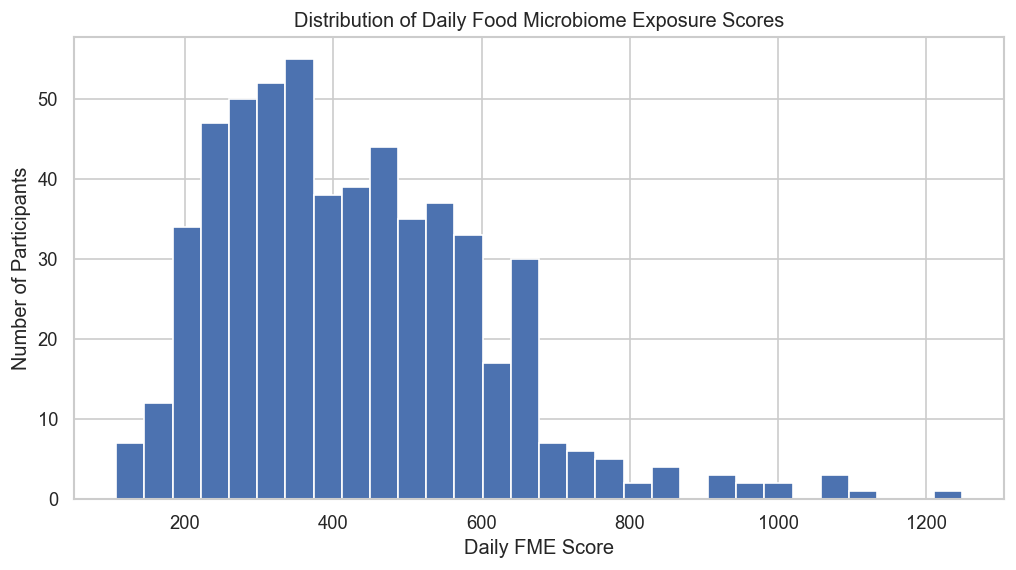

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    fme_scores["daily_FME_score"],
    bins=30
)

plt.xlabel("Daily FME Score")
plt.ylabel("Number of Participants")
plt.title("Distribution of Daily Food Microbiome Exposure Scores")

plt.show()

In [42]:
# Step 9 — Prepare Statistical Dataset
#This section prepares the participant-level Food Microbiome Exposure dataset for downstream statistical analysis.

statistical_data = fme_scores.copy()

print(statistical_data.shape)

statistical_data.head()

(566, 2)


,participant_id,daily_FME_score
0,MCT.f.0001,386.843030
1,MCT.f.0002,562.638300
2,MCT.f.0003,467.912691
3,MCT.f.0004,477.753611
4,MCT.f.0005,429.553252


In [43]:
# ============================================================
# STEP 10 — Export Final Files
# ============================================================

long_df.to_csv(
    "mapped_food_microbiome_data.csv",
    index=False
)

statistical_data.to_csv(
    "daily_fme_scores.csv",
    index=False
)

print("Files saved successfully.")
print("mapped_food_microbiome_data.csv")
print("daily_fme_scores.csv")

Files saved successfully.
mapped_food_microbiome_data.csv
daily_fme_scores.csv
